In [1]:
import os
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from pennylane.templates import StronglyEntanglingLayers


In [4]:
np.random.seed(42)

def square_loss(targets, predictions):
    
    loss = 0
    for (t,p) in zip(targets,predictions):
        loss += (t-p)**2

    loss = 0.5 * (loss/len(targets))
    return loss

In [16]:
n_ansatz_layers = 1
n_layers = 5
n_qubits = 5


In [23]:
dev_parallel = qml.device("default.qubit", wires = n_qubits)

def S(x):
    for w in range(n_qubits):
        qml.RY(x[w], wires = w)

def W(theta):
    
    for l in range(n_ansatz_layers):
        for w in range(n_qubits):
            qml.Rot(theta[l,w,0], theta[l,w,1], theta[l,w,2], wires = w)

        for w in range(n_qubits-1):
            qml.CNOT(wires = [w, w+1])

        qml.CNOT(wires = [n_qubits-1,0])


@qml.qnode(dev_parallel)
def circuit_parallel(params, x=None):
    for l in range(n_layers):
        S(x)
        W(params[l])
    
    #W(params[n_layers-1])

    [qml.expval(qml.PauliZ(wires = i)) for i in range(n_qubits)]

In [24]:
params_parallel = 2 * np.pi * np.random.random( size = (n_layers, n_ansatz_layers, n_qubits, 3))
print(params_parallel)

[[[[3.09525482 0.07133705 2.94468166]
   [0.35376391 0.74655499 0.73843919]
   [4.07910863 4.68753822 3.66541405]
   [6.04550842 2.35538132 1.79518198]
   [5.45756928 1.40489409 6.05210571]]]


 [[[0.07636882 6.09392839 0.27118172]
   [5.59921732 3.31564386 6.23898182]
   [0.46367749 3.4799691  6.09030745]
   [3.28672069 3.95462828 4.37151794]
   [2.85596574 3.94306371 3.6713551 ]]]


 [[[5.66214277 0.28554803 1.76534378]
   [5.97161147 5.59369233 2.86297581]
   [3.89640803 1.74283737 1.18200011]
   [2.913503   2.22017753 3.66721951]
   [0.48842113 6.12230314 6.19654486]]]


 [[[4.38667942 3.36839281 1.94481937]
   [5.11322491 4.30229284 1.02175236]
   [5.7235243  5.16815392 5.96776886]
   [4.55983015 3.85420135 2.6278985 ]
   [5.8605059  5.44163991 0.28411728]]]


 [[[0.16566859 2.3653891  5.09285678]
   [6.20323887 0.9450972  3.73303338]
   [2.39320783 6.09415189 5.29118924]
   [5.2673746  2.94488598 2.6063878 ]
   [1.7178673  0.35421769 5.43321093]]]]


(<Figure size 3800x600 with 1 Axes>, <Axes: >)

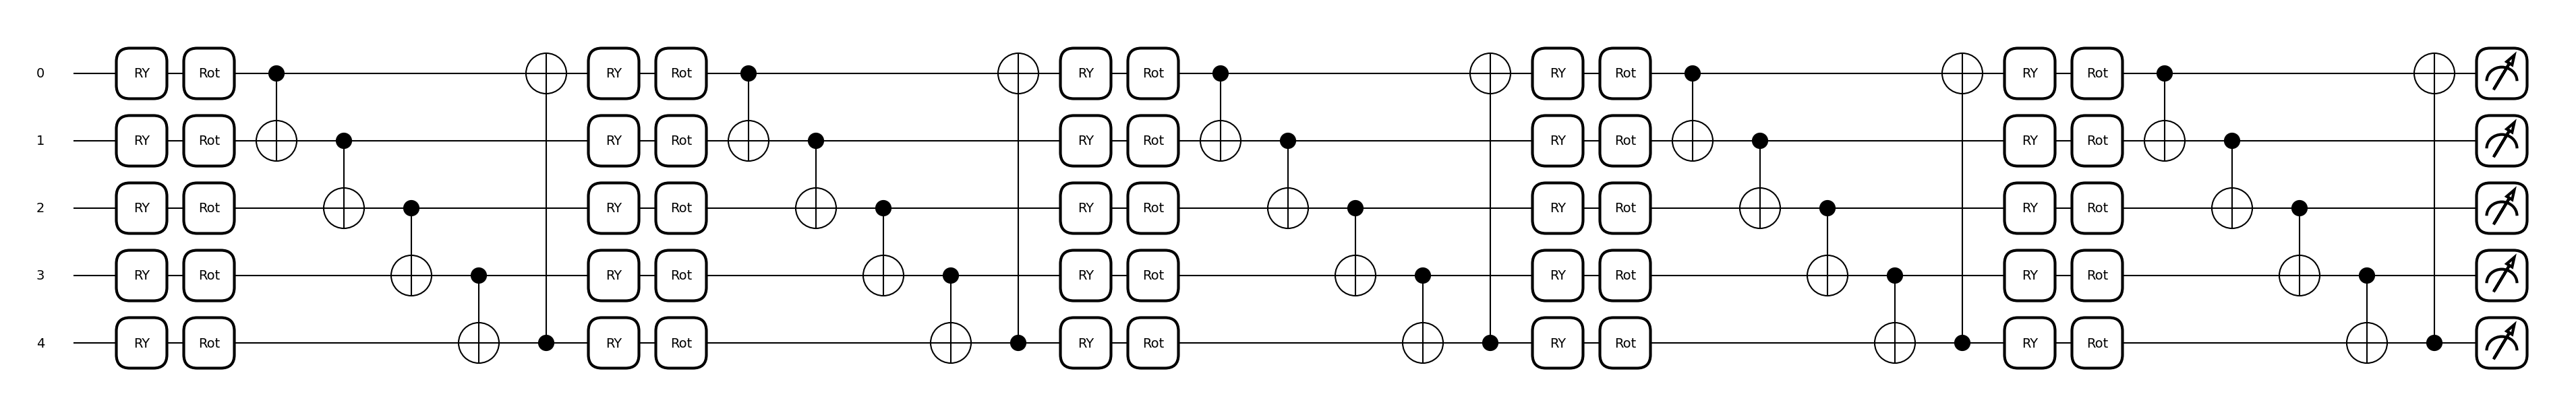

In [25]:
x1 = [0.5, 0.5, 0.5, 0.5, 0.5]
qml.draw_mpl(circuit_parallel)(params_parallel, x=x1)
#fig, ax = qml.draw_mpl(circuit_parallel, level="device")(params_parallel, x=x)
#plt.show()


In [22]:
def cost(params, x , y):
    predictions = [ circuit_parallel(params, x = x_) for x_ in x]
    return square_loss(y, predictions)